In [ ]:
import pandas as pd
df = pd.read_csv('student_performance.csv')

# first 5 rows
df.head()

,student_id,weekly_self_study_hours,attendance_percentage,class_participation,total_score,grade
0,1,18.5,95.6,3.8,97.9,A
1,2,14.0,80.0,2.5,83.9,B
2,3,19.5,86.3,5.3,100.0,A
3,4,25.7,70.2,7.0,100.0,A
4,5,13.4,81.9,6.9,92.0,A


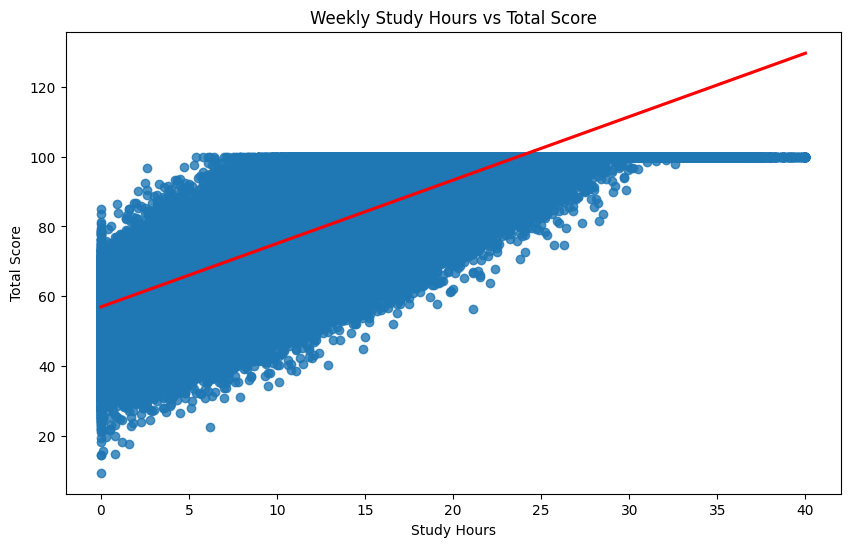

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Study hours & Total Score
plt.figure(figsize=(10, 6))
sns.regplot(x='weekly_self_study_hours', y='total_score', data=df, line_kws={"color": "red"})
plt.title('Weekly Study Hours vs Total Score')
plt.xlabel('Study Hours')
plt.ylabel('Total Score')
plt.show()

In [ ]:
# removing unwanted columns
df_cleaned = df.drop(['student_id', 'grade'], axis=1)

# Data struc
print(df_cleaned.head())

# Check if there are any empty (null) values
print("\nMissing values check:")
print(df_cleaned.isnull().sum())

   weekly_self_study_hours  attendance_percentage  class_participation  \
0                     18.5                   95.6                  3.8   
1                     14.0                   80.0                  2.5   
2                     19.5                   86.3                  5.3   
3                     25.7                   70.2                  7.0   
4                     13.4                   81.9                  6.9   

   total_score  
0         97.9  
1         83.9  
2        100.0  
3        100.0  
4         92.0  

Missing values check:
weekly_self_study_hours    0
attendance_percentage      0
class_participation        1
total_score                1
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

# Features (Api predict karanna use karana dewal)
X = df_cleaned.drop('total_score', axis=1)

# Target (Api predict karanna ona de)
y = df_cleaned['total_score']

# (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (211941, 3)
Testing data size: (52986, 3)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# 1.create model
model = LinearRegression()


In [ ]:
# 2. train the model
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
# 1. checking missing values
print(df.isnull().sum())

# 2. remove missing values rows
df = df.dropna()

# 3. Ayeth check karamu
print("After cleaning:")
print(df.isnull().sum())

student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        1
total_score                1
grade                      1
dtype: int64
After cleaning:
student_id                 0
weekly_self_study_hours    0
attendance_percentage      0
class_participation        0
total_score                0
grade                      0
dtype: int64


In [ ]:
X = df[['weekly_self_study_hours', 'attendance_percentage', 'class_participation']]
y = df['total_score']

# Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X and y defined successfully with correct column names!")

X and y defined successfully with correct column names!


In [ ]:
# 3. Predict
predictions = model.predict(X_test)


In [ ]:
# 4. Accuracy
print("Mean Absolute Error:", mean_absolute_error(y_test, predictions))
print("R2 Score (Accuracy):", r2_score(y_test, predictions))

Mean Absolute Error: 7.168075394005801
R2 Score (Accuracy): 0.6580222599615474


In [ ]:
#Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

# Model eka hadamu (N trees = 100 kiyala gannawa)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_predictions = rf_model.predict(X_test)

#Accuracy
print("Random Forest Mean Absolute Error:", mean_absolute_error(y_test, rf_predictions))
print("Random Forest R2 Score:", r2_score(y_test, rf_predictions))

Random Forest Mean Absolute Error: 6.609101480102479
Random Forest R2 Score: 0.6626152188614719


In [ ]:
#make  artificial neural network (deep learning)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#Neural Network structure
dl_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), # Input Layer
    Dense(32, activation='relu'),                                 # Hidden Layer
    Dense(1)                                                      # Output Layer (Score eka nisa)
])

# Compile
dl_model.compile(optimizer='adam', loss='mean_squared_error')

# Train  (Epochs = 10 ganna)
dl_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

#  Predict
dl_predictions = dl_model.predict(X_test)

#  Accuracy
print("Neural Network R2 Score:", r2_score(y_test, dl_predictions))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
5299/5299 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - loss: 285.8011 - val_loss: 90.0382
Epoch 2/10
5299/5299 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 85.3237 - val_loss: 72.3334
Epoch 3/10
5299/5299 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 74.0024 - val_loss: 71.8109
Epoch 4/10
5299/5299 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 73.0490 - val_loss: 69.6783
Epoch 5/10
5299/5299 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 72.4978 - val_loss: 68.8834
Epoch 6/10
5299/5299 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 70.5382 - val_loss: 68.3167
Epoch 7/10
5299/5299 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 70.0367 - val_loss: 67.6039
Epoch 8/10
5299/5299 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 69.9135 - val_loss: 72.6260
Epoch 9/10
5299/5299 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - loss: 70.2369 - val_loss: 68.4629
Epoch 10/10
5299/5299 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 69.8289 - val_loss: 66.8767
1656/1656 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
Neural Network R2 Score: 0.713528273055837


/tmp/ipython-input-565263721.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')


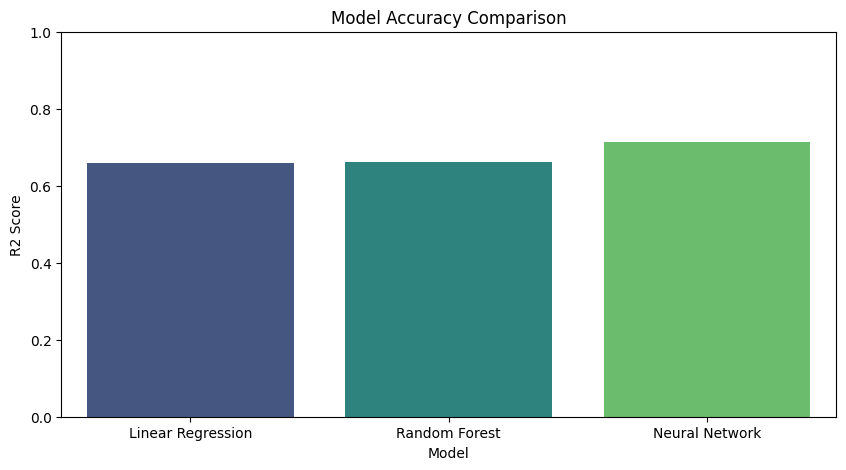

               Model  R2 Score
0  Linear Regression  0.660000
1      Random Forest  0.662615
2     Neural Network  0.713528


In [ ]:
#comparison
import pandas as pd

# Results table
results = {
    'Model': ['Linear Regression', 'Random Forest', 'Neural Network'],
    'R2 Score': [0.66, r2_score(y_test, rf_predictions), r2_score(y_test, dl_predictions)]
}

results_df = pd.DataFrame(results)

# Graph
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='R2 Score', data=results_df, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1) # 0 to 100%
plt.show()

print(results_df)

In [ ]:
import numpy as np

def predict_score(hours, attendance, participation):
    # Model ekata therenna data format karamu
    input_data = np.array([[hours, attendance, participation]])

    # Deep Learning model  use and predict
    prediction = dl_model.predict(input_data)

    return prediction[0][0]


# Satiyata paya 20k paadam karana, 90% attendance thiyena, 8/10 participation thiyena student kenek
my_score = predict_score(20, 90, 8)

print(f"Predicted Total Score: {my_score:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Predicted Total Score: 96.51


In [ ]:
#save the model
import joblib

# ML models save  (.pkl files)
joblib.dump(model, 'linear_model.pkl')
joblib.dump(rf_model, 'random_forest_model.pkl')

# Deep Learning model saving new format
dl_model.save('neural_network_model.keras')

print("Model saved in new format!")

print("All models saved successfully!")

Model saved in new format!
All models saved successfully!
